In [1]:
import torch
import onnxruntime as ort
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

# Mostrar dispositivos ONNX Runtime
providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
print("Proveedores ORT configurados:", providers)


PyTorch: 2.10.0+cu130
CUDA disponible: True
Proveedores ORT configurados: ['CUDAExecutionProvider', 'CPUExecutionProvider']


En esta sección se verifica que el entorno tiene soporte para PyTorch con CUDA y para ONNX Runtime, que será el motor de inferencia principal para el modelo RT‑DETR exportado a ONNX

In [2]:
model_path = "rtdetr-l.onnx" 

session = ort.InferenceSession(model_path, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()[0]

print(" Modelo ONNX cargado:", model_path)
print("Input name:", input_meta.name)
print("Input shape:", input_meta.shape)
print("Output name:", output_meta.name)
print("Output shape:", output_meta.shape)
print("Providers activos:", session.get_providers())


 Modelo ONNX cargado: rtdetr-l.onnx
Input name: images
Input shape: [1, 3, 640, 640]
Output name: output0
Output shape: [1, 300, 84]
Providers activos: ['CPUExecutionProvider']


Aquí se carga el modelo RT‑DETR en formato ONNX con ONNX Runtime. Se observa que la forma de salida es (1, 300, 84), correspondiente a 300 queries y 84 valores (4 cajas + 80 scores de clases COCO).

In [3]:
IN_H, IN_W = input_meta.shape[2], input_meta.shape[3]
CONF_THRESHOLD = 0.5
PERSON_CLASS_ID = 0  # COCO: 0 = person

def preprocess_image_bgr(image_bgr, in_w=IN_W, in_h=IN_H):
    """Resize + padding + normalización, devuelve tensor [1,3,H,W], escala y tamaño original."""
    orig_h, orig_w = image_bgr.shape[:2]

    scale = min(in_w / orig_w, in_h / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    resized = cv2.resize(image_bgr, (new_w, new_h))
    canvas = np.full((in_h, in_w, 3), 114, dtype=np.uint8)
    canvas[:new_h, :new_w] = resized

    img_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
    img = img_rgb.astype(np.float32) / 255.0
    img = img.transpose(2, 0, 1)  # HWC -> CHW
    img = np.expand_dims(img, 0)  # [1,3,H,W]

    return img, scale, (orig_h, orig_w)

def postprocess_rtdetr(outputs, scale, orig_shape,
                       conf_threshold=CONF_THRESHOLD,
                       person_class_id=PERSON_CLASS_ID):
    """Convierte salida (1,300,84) a lista de detecciones en coords de la imagen original."""
    preds = outputs[0][0]        # (300, 84)
    boxes = preds[:, 0:4]        # xc, yc, w, h normalizados
    class_scores = preds[:, 4:]  # (300,80)

    class_ids = np.argmax(class_scores, axis=1)
    scores = class_scores[np.arange(class_scores.shape[0]), class_ids]

    detections = []
    orig_h, orig_w = orig_shape

    for i in range(preds.shape[0]):
        score = float(scores[i])
        cls = int(class_ids[i])

        if score < conf_threshold:
            continue
        if cls != person_class_id:
            continue

        xc, yc, w, h = boxes[i]

        # Canvas
        xc *= IN_W
        yc *= IN_H
        w *= IN_W
        h *= IN_H

        x1 = int(xc - w / 2)
        y1 = int(yc - h / 2)
        x2 = int(xc + w / 2)
        y2 = int(yc + h / 2)

        # Reescalar a original
        x1 = int(x1 / scale)
        y1 = int(y1 / scale)
        x2 = int(x2 / scale)
        y2 = int(y2 / scale)

        x1 = max(0, min(x1, orig_w - 1))
        y1 = max(0, min(y1, orig_h - 1))
        x2 = max(0, min(x2, orig_w - 1))
        y2 = max(0, min(y2, orig_h - 1))

        detections.append({
            "bbox": [x1, y1, x2, y2],
            "score": score,
            "class_id": cls,
            "class_name": "person"
        })

    return detections

def draw_detections(image_bgr, detections):
    img = image_bgr.copy()
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        score = det["score"]
        label = f"{det['class_name']} {score:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1-20), (x1+tw, y1), (0,255,0), -1)
        cv2.putText(img, label, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()


Estas funciones encapsulan el mismo pipeline que usa el backend: preprocesado con resize/padding, inferencia con ONNX Runtime, postprocesado para recuperar bounding boxes en coordenadas de la imagen original y una función auxiliar para visualizar las detecciones.

Tiempo de inferencia: 249.62 ms
Personas detectadas: 1
  det 0: bbox=[115, 64, 138, 276], score=0.719


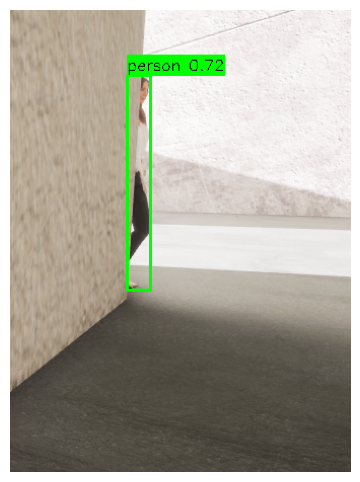

In [31]:
image_path = "output/personUnreal2.png"

image_bgr = cv2.imread(image_path)
assert image_bgr is not None, "No se pudo cargar la imagen"

inp, scale, orig_shape = preprocess_image_bgr(image_bgr)
t0 = time.time()
outputs = session.run(None, {input_meta.name: inp})
dt = (time.time() - t0) * 1000

detections = postprocess_rtdetr(outputs, scale, orig_shape)

print(f"Tiempo de inferencia: {dt:.2f} ms")
print(f"Personas detectadas: {len(detections)}")
for i, d in enumerate(detections):
    print(f"  det {i}: bbox={d['bbox']}, score={d['score']:.3f}")

draw_detections(image_bgr, detections)


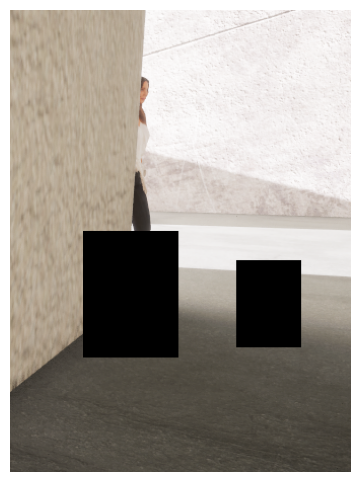

In [32]:
import random

def apply_random_occlusion(image_bgr, max_boxes=3, max_frac=0.4):
    """
    Aplica rectángulos negros aleatorios para simular oclusión.
    max_boxes: máximo número de bloques
    max_frac: proporción máxima del ancho/alto cubierta por bloque
    """
    img = image_bgr.copy()
    h, w = img.shape[:2]
    num_boxes = random.randint(1, max_boxes)

    for _ in range(num_boxes):
        bw = int(random.uniform(0.1, max_frac) * w)
        bh = int(random.uniform(0.1, max_frac) * h)
        x1 = random.randint(0, max(0, w - bw))
        y1 = random.randint(0, max(0, h - bh))
        x2 = x1 + bw
        y2 = y1 + bh
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 0), -1)
    return img

# Ejemplo visual de oclusión
occluded = apply_random_occlusion(image_bgr, max_boxes=2, max_frac=0.35)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(occluded, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


Imagen limpia:
  tiempo: 248.13 ms, personas: 1
  {'bbox': [115, 64, 138, 276], 'score': 0.7185096144676208, 'class_id': 0, 'class_name': 'person'}


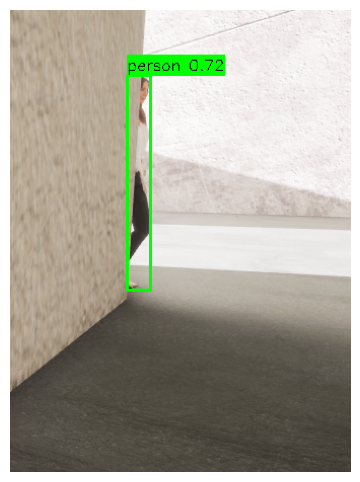

Imagen con oclusiones sintéticas:
  tiempo: 250.70 ms, personas: 1
  {'bbox': [121, 64, 137, 173], 'score': 0.7643967270851135, 'class_id': 0, 'class_name': 'person'}


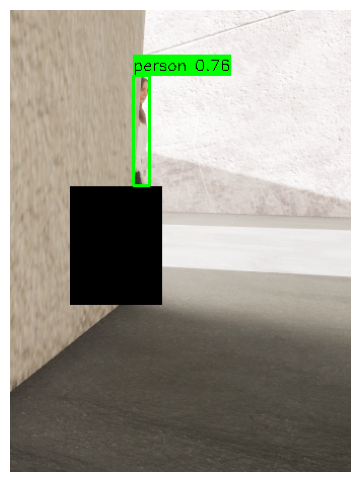

In [38]:
def run_detection(image_bgr):
    inp, scale, orig_shape = preprocess_image_bgr(image_bgr)
    t0 = time.time()
    outputs = session.run(None, {input_meta.name: inp})
    dt = (time.time() - t0) * 1000
    dets = postprocess_rtdetr(outputs, scale, orig_shape)
    return dets, dt

# Original
dets_clean, dt_clean = run_detection(image_bgr)
print("Imagen limpia:")
print(f"  tiempo: {dt_clean:.2f} ms, personas: {len(dets_clean)}")
for d in dets_clean:
    print(" ", d)

draw_detections(image_bgr, dets_clean)

# Ocluida
occluded = apply_random_occlusion(image_bgr, max_boxes=2, max_frac=0.35)
dets_occ, dt_occ = run_detection(occluded)
print("Imagen con oclusiones sintéticas:")
print(f"  tiempo: {dt_occ:.2f} ms, personas: {len(dets_occ)}")
for d in dets_occ:
    print(" ", d)

draw_detections(occluded, dets_occ)


Aquí se simulan oclusiones “pegando” rectángulos negros sobre la imagen y se compara el número de detecciones y los scores de confianza antes y después. Esto conecta directamente con el diseño de niveles de StealthVision, donde columnas, paredes y otros objetos en el entorno generan oclusión parcial del jugador frente a la cámara.

In [39]:
results = []

for frac in [0.0, 0.15, 0.3, 0.45]:
    # 0.0 = sin oclusión
    if frac == 0.0:
        test_img = image_bgr
    else:
        test_img = apply_random_occlusion(image_bgr, max_boxes=2, max_frac=frac)

    dets, dt = run_detection(test_img)
    avg_score = np.mean([d["score"] for d in dets]) if dets else 0.0

    results.append({
        "max_frac": frac,
        "count": len(dets),
        "avg_score": avg_score,
        "time_ms": dt,
    })

import pandas as pd

df = pd.DataFrame(results)
df


,max_frac,count,avg_score,time_ms
0,0.00,1,0.718510,284.621954
1,0.15,1,0.639310,245.209694
2,0.30,1,0.540816,243.538618
3,0.45,1,0.718658,236.783981
